# Food Delivery Time Prediction - Single Notebook Project

This notebook is the complete project in one file.

It will:
1. install required lightweight libraries (if missing)
2. load `finaldata.csv`
3. clean and preprocess data
4. train a lightweight model
5. evaluate with MAE and R2
6. plot actual vs predicted
7. save outputs (`model.pkl`, `cleaned_data.csv`, `model_info.json`)
8. allow single-entry prediction (no CSV needed)

In [15]:
# Step 1: Install required libraries if missing
import importlib
import subprocess
import sys
import site

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

for import_name, pip_name in required.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pip_name])
        importlib.invalidate_caches()
        user_site = site.getusersitepackages()
        if user_site and user_site not in sys.path:
            sys.path.append(user_site)

print("Setup complete.")


Setup complete.


In [16]:
# Step 2: Imports
import json
import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor


In [17]:
# Step 3: Helper functions

def normalize_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", name.strip().lower()).strip("_")


def detect_target_column(df: pd.DataFrame) -> str:
    columns = list(df.columns)
    normalized = {col: normalize_name(col) for col in columns}

    exact_priority = {
        "delivery_time",
        "delivery_time_min",
        "delivery_time_minutes",
        "time",
        "time_taken",
        "time_taken_min",
        "time_taken_minutes",
    }

    exact_matches = [col for col in columns if normalized[col] in exact_priority]
    if exact_matches:
        return exact_matches[0]

    delivery_time_candidates = [
        col for col in columns if "delivery" in normalized[col] and "time" in normalized[col]
    ]
    if delivery_time_candidates:
        return delivery_time_candidates[0]

    time_candidates = [col for col in columns if "time" in normalized[col]]
    if time_candidates:
        numeric_candidates = [
            col for col in time_candidates if str(df[col].dtype).startswith(("int", "float"))
        ]
        return numeric_candidates[0] if numeric_candidates else time_candidates[0]

    raise ValueError("No delivery time target column found.")


def make_target_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")

    converted = pd.to_numeric(series, errors="coerce")
    if converted.notna().mean() >= 0.6:
        return converted

    return (
        series.astype(str)
        .str.extract(r"([-+]?\d*\.?\d+)", expand=False)
        .pipe(pd.to_numeric, errors="coerce")
    )


def detect_identifier_columns(columns) -> list:
    identifier_columns = []
    for col in columns:
        normalized = normalize_name(col)
        if normalized == "id" or normalized.endswith("_id") or normalized in {"order_id", "delivery_id"}:
            identifier_columns.append(col)
    return identifier_columns


def build_preprocessor(numeric_cols, categorical_cols):
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", encoder),
                ]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100


In [18]:
# Step 4: Load dataset
csv_file = "finaldata.csv"
df = pd.read_csv(csv_file)

print(f"Loaded: {csv_file}")
print(f"Shape: {df.shape}")
print("Columns:")
print(list(df.columns))
print("First 5 rows:")
display(df.head())

Loaded: finaldata.csv
Shape: (1000, 9)
Columns:
['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
First 5 rows:


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Extra Visual Analysis (EDA + Heatmaps)

These charts help explain the data and model behavior for presentation.


Numeric columns: ['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
Categorical columns: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


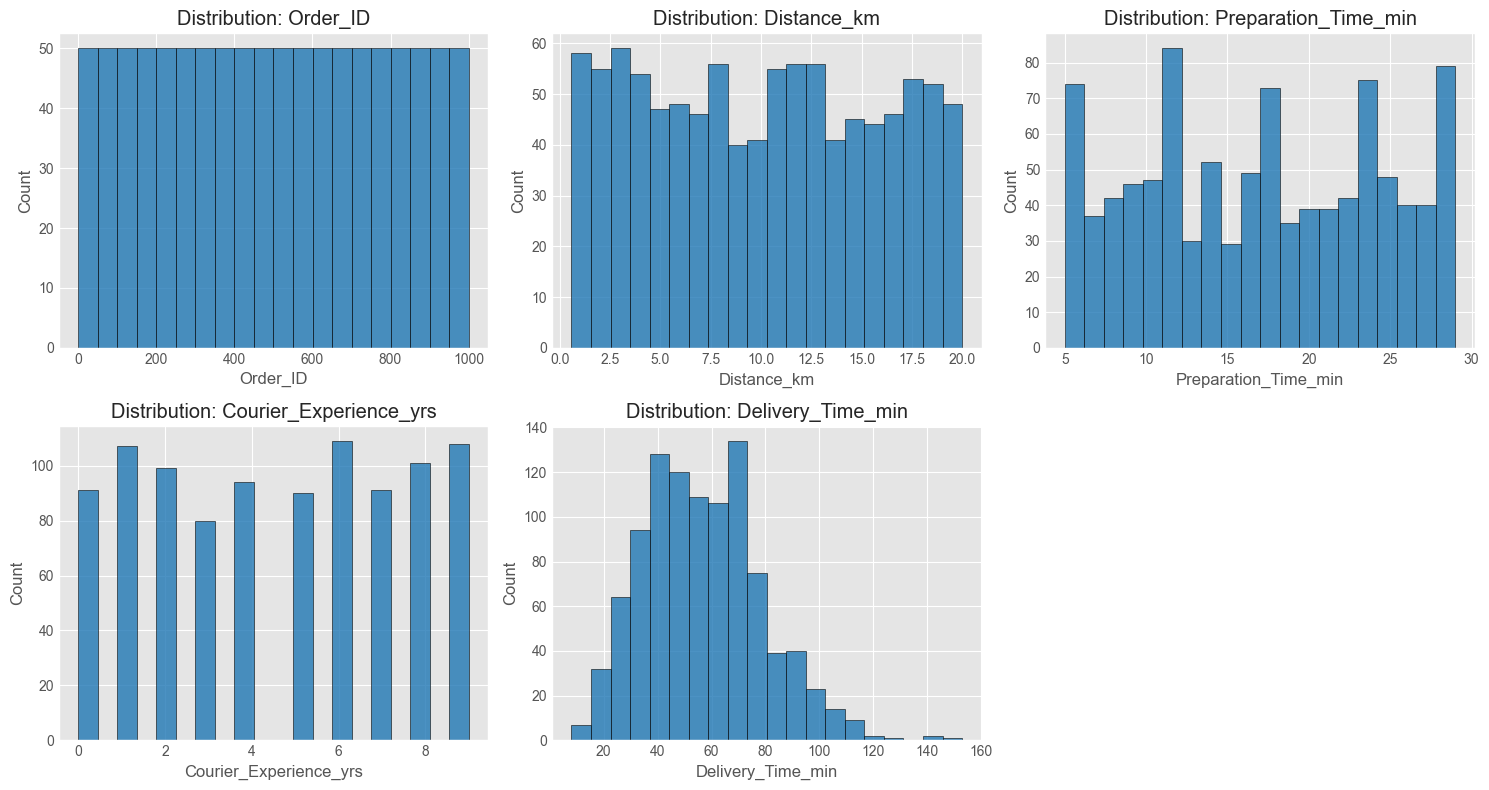

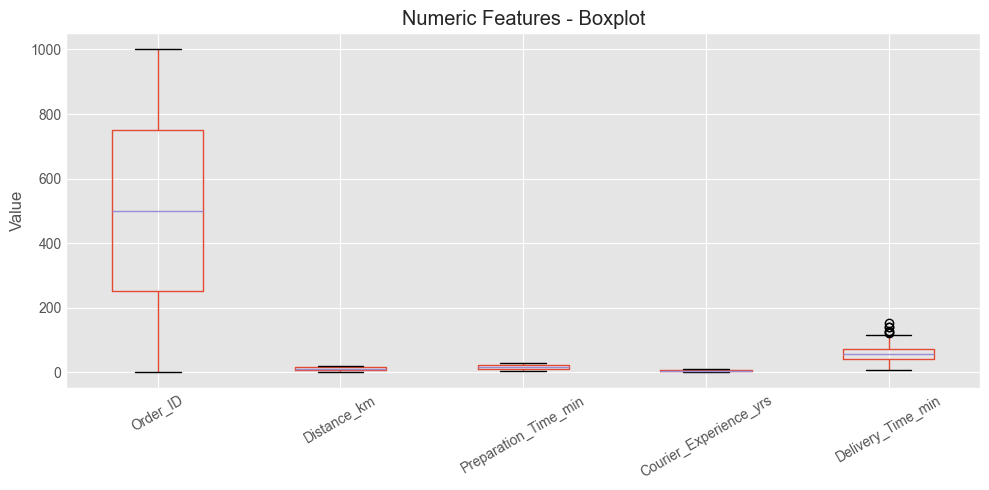

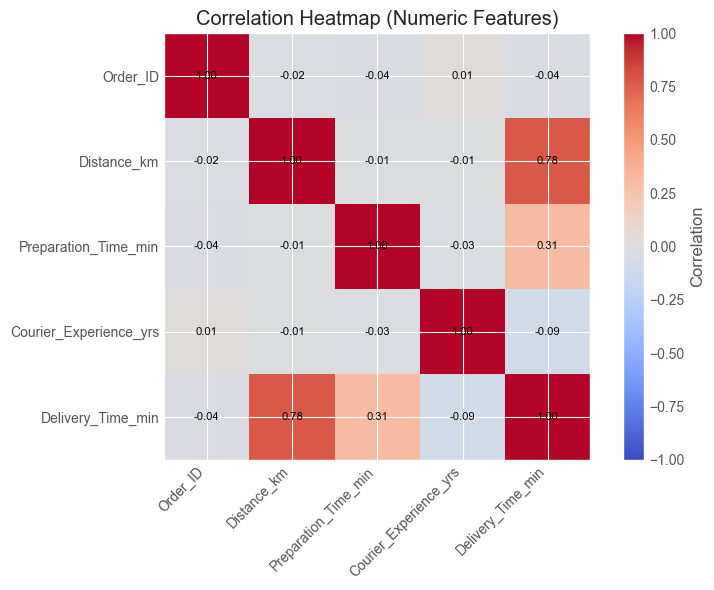

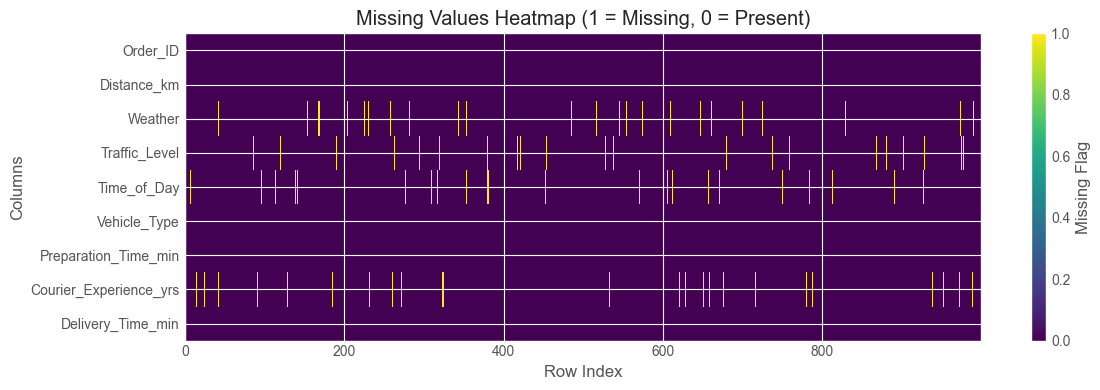

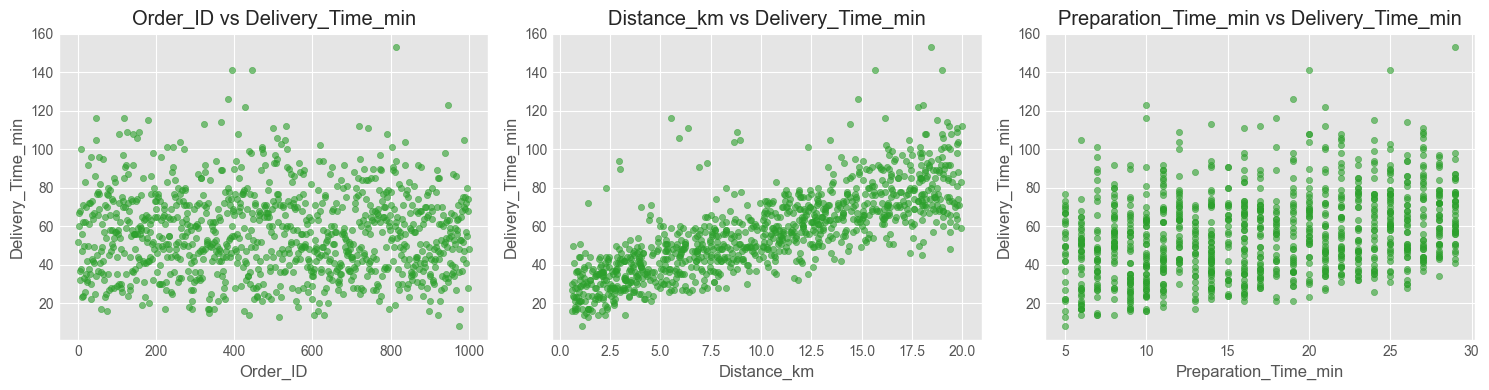

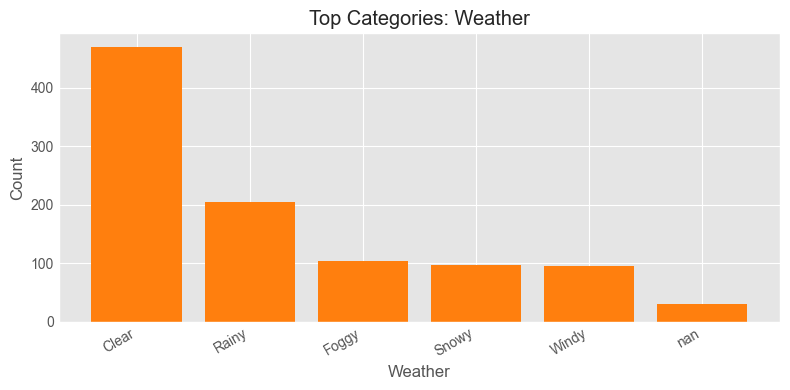

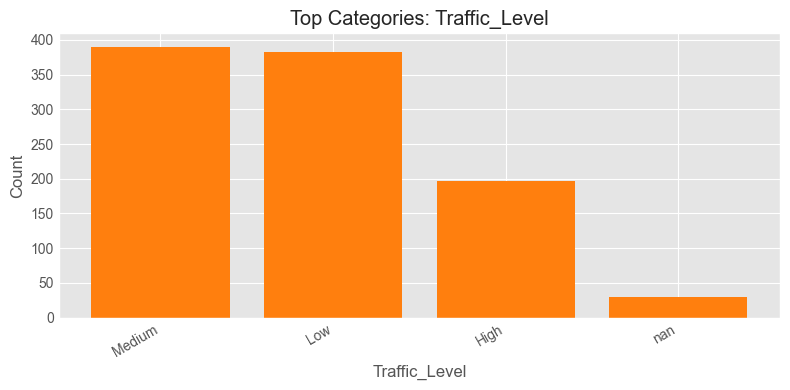

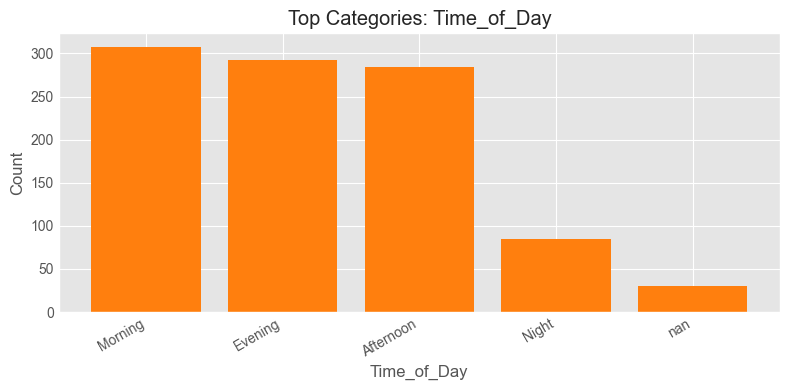

In [19]:
# Step 4.1: Rich visual analysis (lightweight)
import matplotlib.pyplot as plt

# Local style for cleaner charts
plt.style.use('ggplot')

# Identify columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

# 1) Histograms for numeric columns
if num_cols:
    n = len(num_cols)
    rows = (n + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(num_cols):
        axes[i].hist(df[col].dropna(), bins=20, color='#1f77b4', edgecolor='black', alpha=0.8)
        axes[i].set_title(f'Distribution: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# 2) Boxplots for numeric columns (outlier view)
if num_cols:
    plt.figure(figsize=(max(10, len(num_cols) * 1.5), 5))
    df[num_cols].boxplot(rot=30)
    plt.title('Numeric Features - Boxplot')
    plt.ylabel('Value')
    plt.tight_layout()
    plt.show()

# 3) Correlation heatmap (matplotlib only)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr.index)
    ax.set_title('Correlation Heatmap (Numeric Features)')

    # Annotate values
    for r in range(corr.shape[0]):
        for c in range(corr.shape[1]):
            ax.text(c, r, f"{corr.iloc[r, c]:.2f}", ha='center', va='center', color='black', fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Correlation')
    plt.tight_layout()
    plt.show()

# 4) Missing values heatmap (boolean matrix)
missing_matrix = df.isna().astype(int)
if missing_matrix.values.sum() > 0:
    plt.figure(figsize=(12, 4))
    plt.imshow(missing_matrix.T, aspect='auto', interpolation='nearest', cmap='viridis')
    plt.yticks(range(len(df.columns)), df.columns)
    plt.xlabel('Row Index')
    plt.ylabel('Columns')
    plt.title('Missing Values Heatmap (1 = Missing, 0 = Present)')
    cbar = plt.colorbar()
    cbar.set_label('Missing Flag')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found, missing-value heatmap skipped.')

# 5) Target vs key numeric features scatter plots
try:
    target_for_viz = detect_target_column(df)
except Exception:
    target_for_viz = None

if target_for_viz and target_for_viz in df.columns:
    candidate_num = [c for c in num_cols if c != target_for_viz]
    top_features = candidate_num[:3]
    if top_features:
        fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 4))
        if len(top_features) == 1:
            axes = [axes]
        for ax, col in zip(axes, top_features):
            ax.scatter(df[col], df[target_for_viz], alpha=0.6, s=20, color='#2ca02c')
            ax.set_xlabel(col)
            ax.set_ylabel(target_for_viz)
            ax.set_title(f'{col} vs {target_for_viz}')
        plt.tight_layout()
        plt.show()

# 6) Category count plots for first few categorical columns
for col in cat_cols[:3]:
    top_counts = df[col].value_counts(dropna=False).head(10)
    plt.figure(figsize=(8, 4))
    plt.bar(top_counts.index.astype(str), top_counts.values, color='#ff7f0e')
    plt.title(f'Top Categories: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [20]:
# Step 5: Clean data and keep <=1000 rows
original_rows = len(df)

df = df.dropna(how="all").copy()
df = df.dropna(axis=1, how="all")

if len(df) > 1000:
    df = df.sample(n=1000, random_state=42).reset_index(drop=True)

print(f"Rows after cleaning/sampling: {original_rows} -> {len(df)}")

Rows after cleaning/sampling: 1000 -> 1000


In [21]:
# Step 6: Detect target + split features
target_col = detect_target_column(df)
print(f"Detected target column: {target_col}")

df[target_col] = make_target_numeric(df[target_col])
df = df.dropna(subset=[target_col]).copy()

X_full = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

identifier_columns = detect_identifier_columns(X_full.columns)
model_columns = [col for col in X_full.columns if col not in identifier_columns]
X = X_full[model_columns].copy()

numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

full_numeric_features = X_full.select_dtypes(include=[np.number, "bool"]).columns.tolist()
full_categorical_features = [c for c in X_full.columns if c not in full_numeric_features]

print("Removed identifier-like columns from modeling:", identifier_columns if identifier_columns else "None")
print("Modeling features:", list(X.columns))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Detected target column: Delivery_Time_min
Removed identifier-like columns from modeling: ['Order_ID']
Modeling features: ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']
Numeric features: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
Categorical features: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


In [22]:
# Step 7: Safe missing value handling and save cleaned data
if full_numeric_features:
    X_full[full_numeric_features] = X_full[full_numeric_features].fillna(X_full[full_numeric_features].median())

if full_categorical_features:
    for col in full_categorical_features:
        mode = X_full[col].mode(dropna=True)
        fill_value = mode.iloc[0] if not mode.empty else "Unknown"
        X_full[col] = X_full[col].fillna(fill_value)

X = X_full[model_columns].copy()

cleaned_df = X_full.copy()
cleaned_df[target_col] = y
cleaned_df.to_csv("cleaned_data.csv", index=False)
print("Saved cleaned_data.csv")


Saved cleaned_data.csv


In [23]:
# Step 8: Build preprocessing and models
train_idx, test_idx = train_test_split(X.index, test_size=0.2, random_state=42)

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

X_full_train = X_full.loc[train_idx].copy()
X_full_test = X_full.loc[test_idx].copy()

preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor_with_id = build_preprocessor(full_numeric_features, full_categorical_features)

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42)),
])

linear_model_with_id = Pipeline([
    ("preprocessor", preprocessor_with_id),
    ("model", LinearRegression()),
])

print(f"Train shape without ID: {X_train.shape}, Test shape without ID: {X_test.shape}")
print(f"Reference experiment shape with ID: {X_full_train.shape}, {X_full_test.shape}")


Train shape without ID: (800, 7), Test shape without ID: (200, 7)
Reference experiment shape with ID: (800, 8), (200, 8)


In [24]:
# Step 9: Train, compare, and validate models
linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
linear_model_with_id.fit(X_full_train, y_train)

y_pred_linear = linear_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_linear_with_id = linear_model_with_id.predict(X_full_test)

residual_linear = y_test.values - y_pred_linear
residual_tree = y_test.values - y_pred_tree

metrics_df = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_test, y_pred_linear),
            mean_absolute_error(y_test, y_pred_tree),
        ],
        "RMSE": [
            mean_squared_error(y_test, y_pred_linear) ** 0.5,
            mean_squared_error(y_test, y_pred_tree) ** 0.5,
        ],
        "MAPE (%)": [
            safe_mape(y_test, y_pred_linear),
            safe_mape(y_test, y_pred_tree),
        ],
        "R2 Score": [
            r2_score(y_test, y_pred_linear),
            r2_score(y_test, y_pred_tree),
        ],
    },
    index=["Linear Regression", "Decision Tree"],
)

id_experiment_df = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_test, y_pred_linear_with_id),
            mean_absolute_error(y_test, y_pred_linear),
        ],
        "RMSE": [
            mean_squared_error(y_test, y_pred_linear_with_id) ** 0.5,
            mean_squared_error(y_test, y_pred_linear) ** 0.5,
        ],
        "R2 Score": [
            r2_score(y_test, y_pred_linear_with_id),
            r2_score(y_test, y_pred_linear),
        ],
    },
    index=["Linear Regression + Order_ID", "Linear Regression without Order_ID"],
)

mae_linear = float(metrics_df.loc["Linear Regression", "MAE"])
rmse_linear = float(metrics_df.loc["Linear Regression", "RMSE"])
mape_linear = float(metrics_df.loc["Linear Regression", "MAPE (%)"])
r2_linear = float(metrics_df.loc["Linear Regression", "R2 Score"])

mae_tree = float(metrics_df.loc["Decision Tree", "MAE"])
rmse_tree = float(metrics_df.loc["Decision Tree", "RMSE"])
mape_tree = float(metrics_df.loc["Decision Tree", "MAPE (%)"])
r2_tree = float(metrics_df.loc["Decision Tree", "R2 Score"])

prediction_comparison = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Linear Regression": np.round(y_pred_linear, 2),
        "Decision Tree": np.round(y_pred_tree, 2),
        "Linear Residual": np.round(residual_linear, 2),
        "Decision Tree Residual": np.round(residual_tree, 2),
        "Linear Abs Error": np.round(np.abs(residual_linear), 2),
        "Tree Abs Error": np.round(np.abs(residual_tree), 2),
    }
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []
for name, model in [("Linear Regression", linear_model), ("Decision Tree", tree_model)]:
    mae_scores = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    cv_summary.append(
        {
            "Model": name,
            "CV MAE Mean": mae_scores.mean(),
            "CV MAE Std": mae_scores.std(),
            "CV R2 Mean": r2_scores.mean(),
            "CV R2 Std": r2_scores.std(),
        }
    )
cv_df = pd.DataFrame(cv_summary).set_index("Model")

print("Model performance summary:")
display(metrics_df.round(3))

print("Prediction comparison sample:")
display(prediction_comparison.head(10))

print("5-fold cross-validation summary:")
display(cv_df.round(3))

print("Feature selection experiment: should we keep Order_ID?")
display(id_experiment_df.round(3))

better_mae = "Linear Regression" if mae_linear < mae_tree else "Decision Tree"
better_r2 = "Linear Regression" if r2_linear > r2_tree else "Decision Tree"

print(
    f"Lower error metrics are better. {better_mae} has the lower MAE "
    f"({min(mae_linear, mae_tree):.2f}) and RMSE ({min(rmse_linear, rmse_tree):.2f})."
)
print(
    f"Higher R2 is better. {better_r2} explains more variation in delivery time "
    f"with an R2 score of {max(r2_linear, r2_tree):.3f}."
)
print(
    "Removing identifier columns is the safer modeling choice because Order_ID is not a real"
    " operational driver of delivery time."
)


Model performance summary:


,MAE,RMSE,MAPE (%),R2 Score
Linear Regression,5.899,8.826,10.407,0.826
Decision Tree,8.774,12.032,17.532,0.677


Prediction comparison sample:


,Actual,Linear Regression,Decision Tree,Linear Residual,Decision Tree Residual,Linear Abs Error,Tree Abs Error
0,32,35.27,50.91,-3.27,-18.91,3.27,18.91
1,68,66.51,71.84,1.49,-3.84,1.49,3.84
2,39,44.64,35.24,-5.64,3.76,5.64,3.76
3,44,43.88,43.27,0.12,0.73,0.12,0.73
4,85,80.02,80.88,4.98,4.12,4.98,4.12
5,31,32.17,43.27,-1.17,-12.27,1.17,12.27
6,77,69.39,64.47,7.61,12.53,7.61,12.53
7,33,32.39,29.97,0.61,3.03,0.61,3.03
8,90,37.49,29.97,52.51,60.03,52.51,60.03
9,91,78.09,73.56,12.91,17.44,12.91,17.44


5-fold cross-validation summary:


,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
Model,,,,
Linear Regression,6.548,0.675,0.773,0.049
Decision Tree,9.223,0.706,0.655,0.043


Feature selection experiment: should we keep Order_ID?


,MAE,RMSE,R2 Score
Linear Regression + Order_ID,5.913,8.855,0.825
Linear Regression without Order_ID,5.899,8.826,0.826


Lower error metrics are better. Linear Regression has the lower MAE (5.90) and RMSE (8.83).
Higher R2 is better. Linear Regression explains more variation in delivery time with an R2 score of 0.826.
Removing identifier columns is the safer modeling choice because Order_ID is not a real operational driver of delivery time.


## Model Comparison Interpretation

The next chart block compares the models from several angles so the conclusion is easier to explain in a report or presentation.

- The scatter plots show how closely each model's predictions follow the ideal diagonal line.
- The bar charts compare core metrics. Lower MAE, RMSE, and MAPE are better, while a higher R2 score is better.
- The metric heatmap gives a compact side-by-side summary of performance.
- The residual plots help show whether one model makes larger or more uneven errors.
- The cross-validation and Order_ID experiment strengthen the project because they show model evaluation and feature-selection reasoning, not just one lucky split.

In this project, the Linear Regression model is the final choice because it is more accurate and more stable across evaluation views.


/var/folders/5j/yt21mc611cl_vfjs09_5sg7c0000gn/T/ipykernel_59864/2127017781.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2, 1].boxplot(


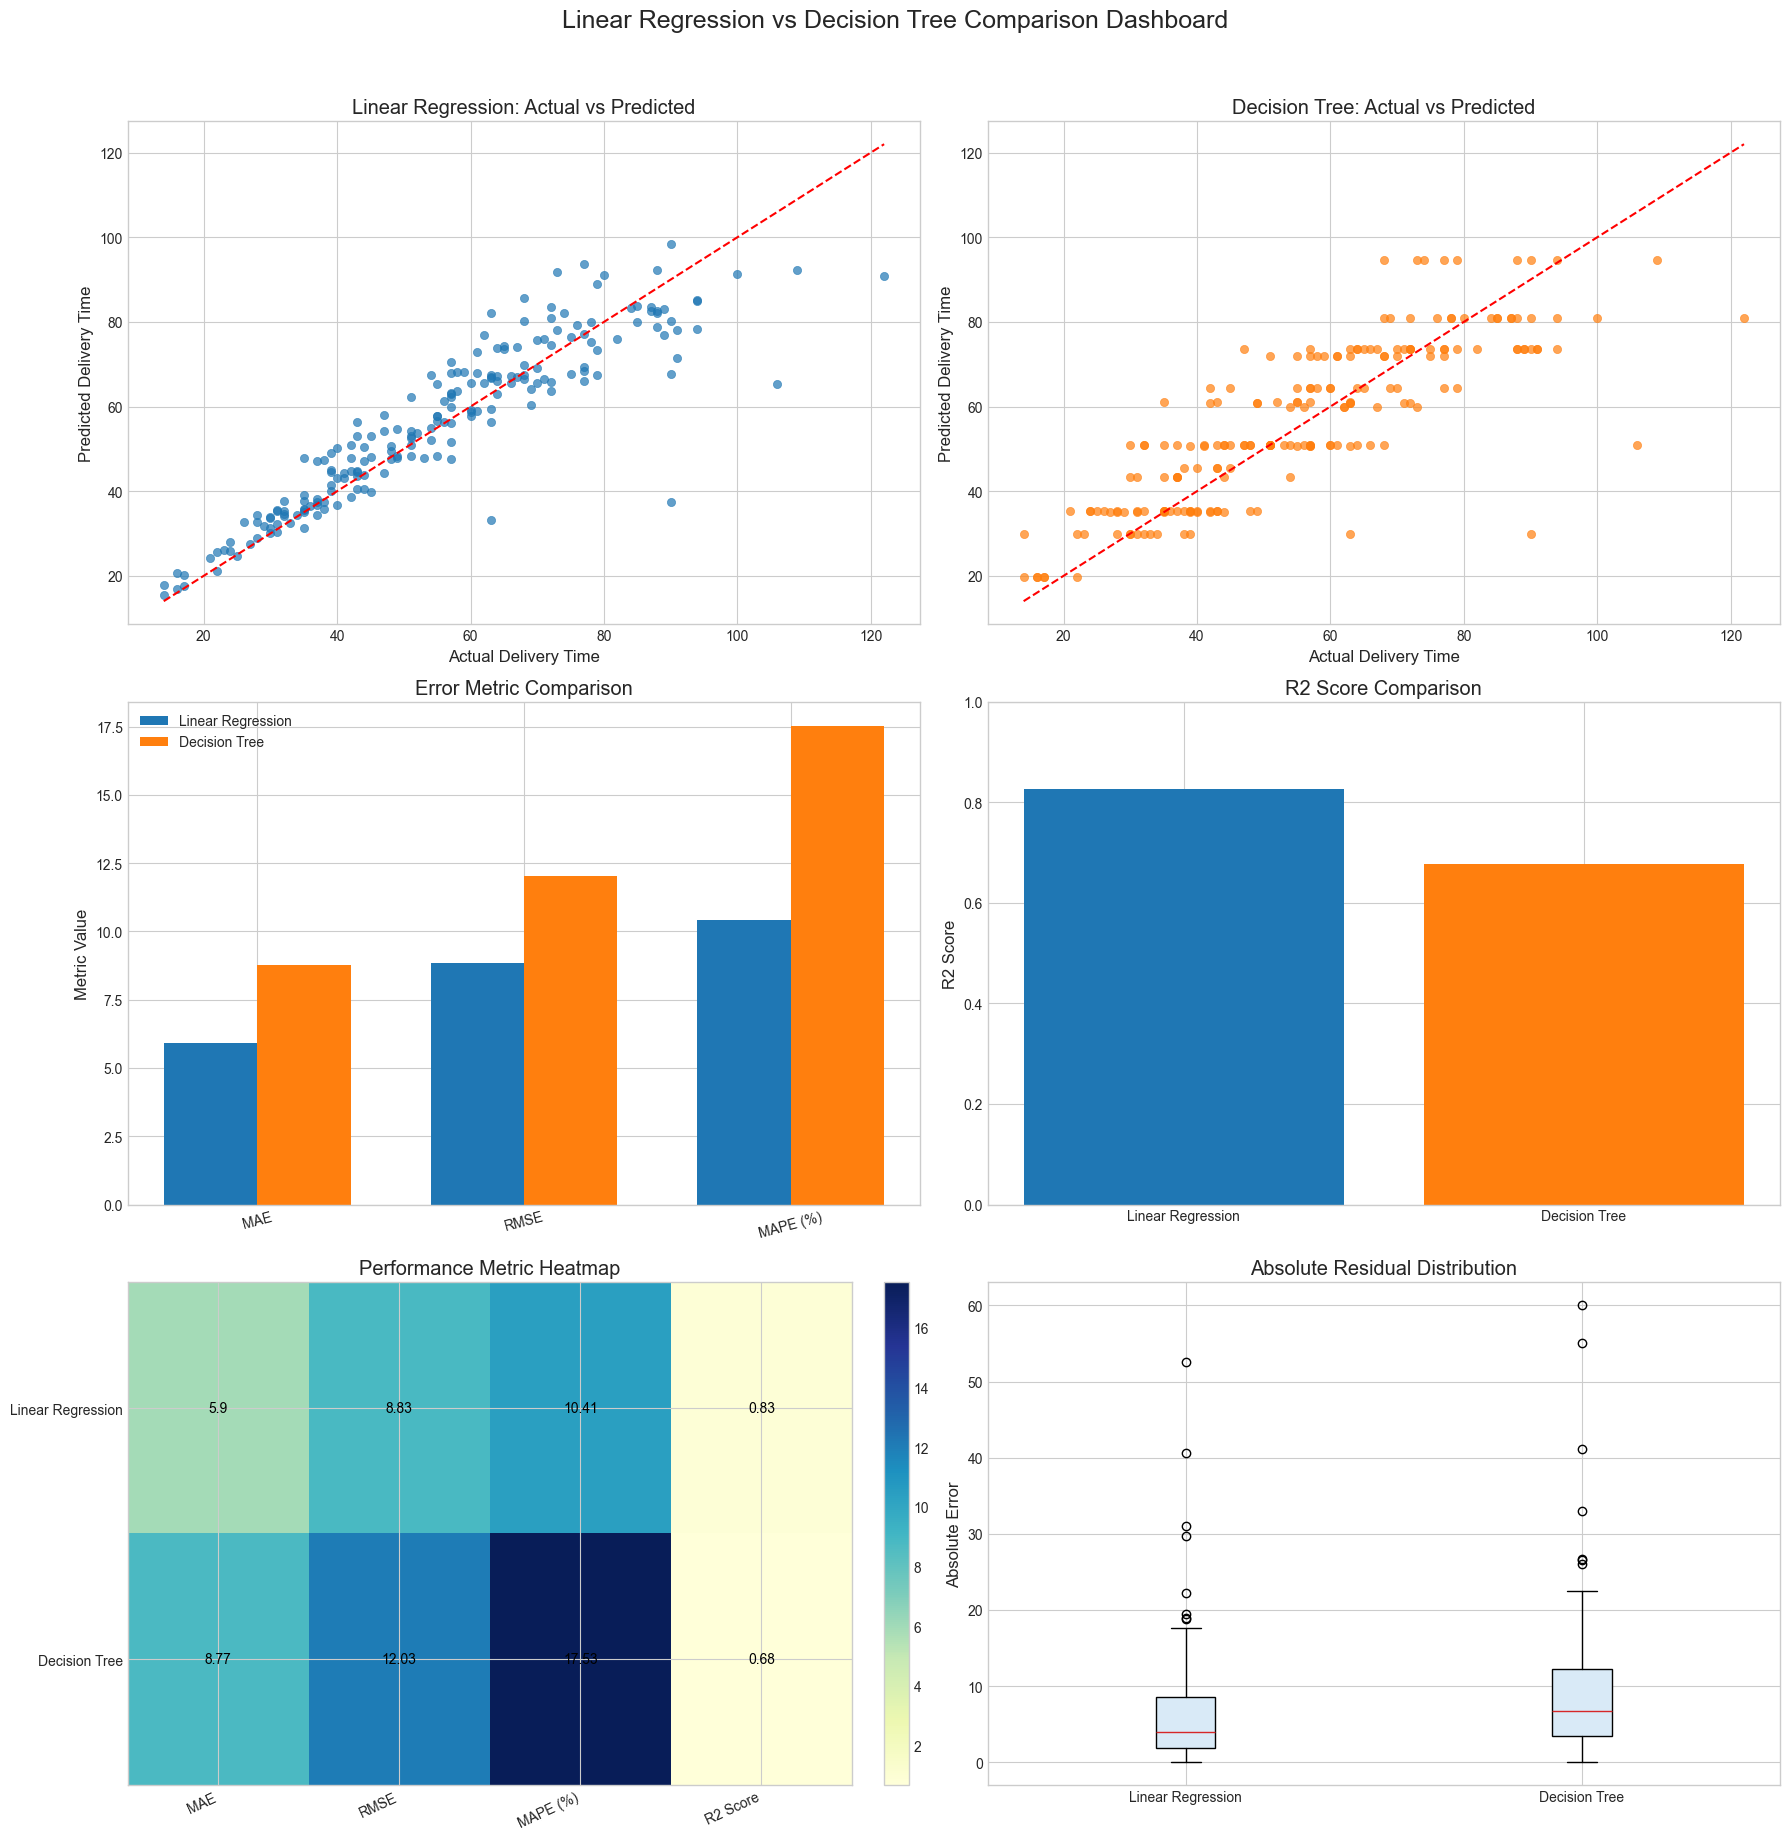

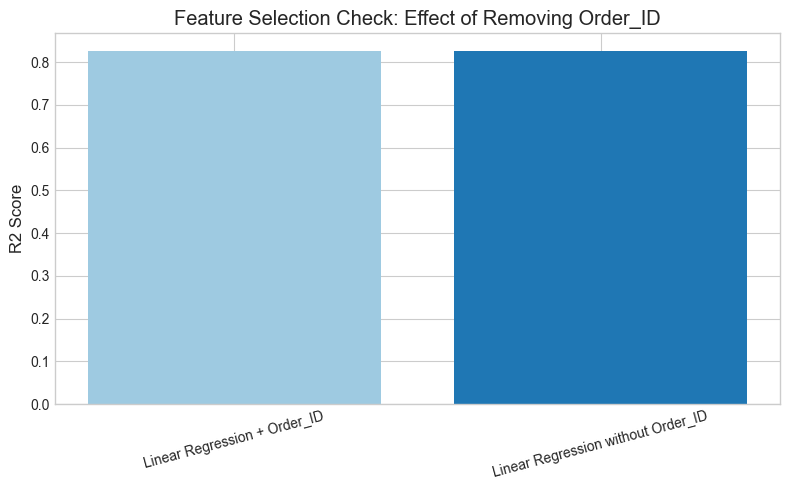

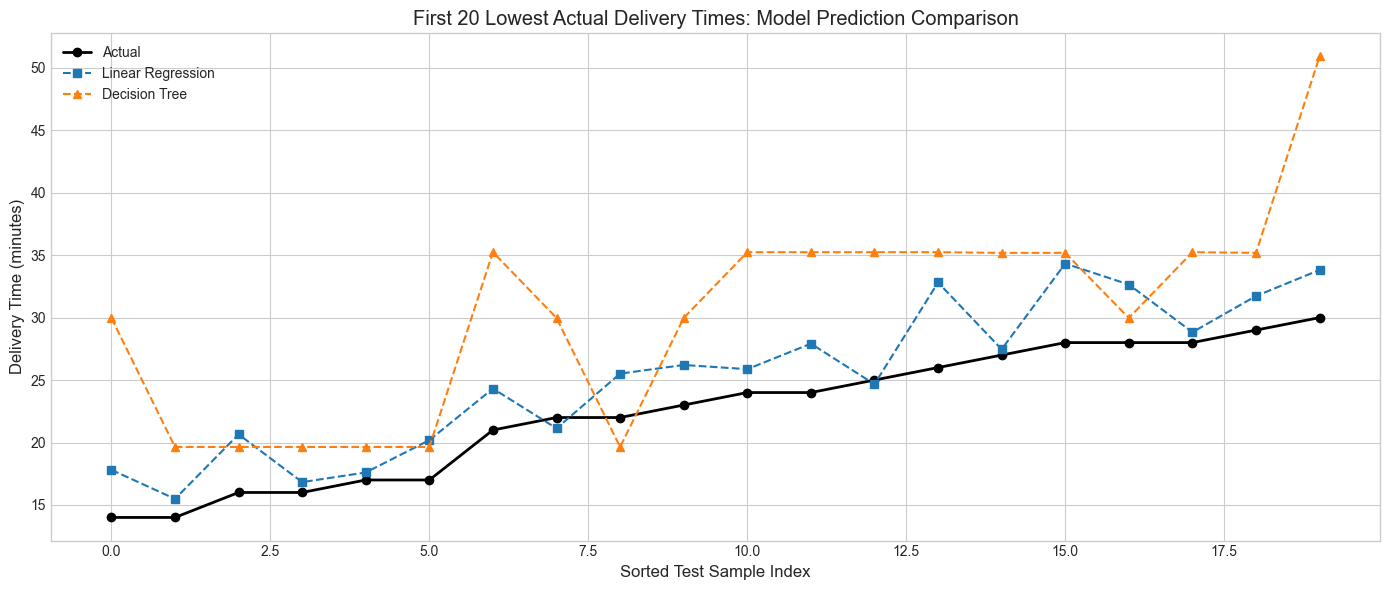

Saved model_comparison_dashboard.png


In [25]:
# Step 10: Visual comparison dashboard
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

min_val = float(min(y_test.min(), np.min(y_pred_linear), np.min(y_pred_tree)))
max_val = float(max(y_test.max(), np.max(y_pred_linear), np.max(y_pred_tree)))
ideal_line = [min_val, max_val]

axes[0, 0].scatter(y_test, y_pred_linear, alpha=0.7, s=35, color="#1f77b4")
axes[0, 0].plot(ideal_line, ideal_line, "r--", linewidth=1.5)
axes[0, 0].set_title("Linear Regression: Actual vs Predicted")
axes[0, 0].set_xlabel("Actual Delivery Time")
axes[0, 0].set_ylabel("Predicted Delivery Time")

axes[0, 1].scatter(y_test, y_pred_tree, alpha=0.7, s=35, color="#ff7f0e")
axes[0, 1].plot(ideal_line, ideal_line, "r--", linewidth=1.5)
axes[0, 1].set_title("Decision Tree: Actual vs Predicted")
axes[0, 1].set_xlabel("Actual Delivery Time")
axes[0, 1].set_ylabel("Predicted Delivery Time")

error_metrics = metrics_df[["MAE", "RMSE", "MAPE (%)"]]
x = np.arange(len(error_metrics.columns))
width = 0.35
axes[1, 0].bar(x - width / 2, error_metrics.loc["Linear Regression"], width, label="Linear Regression", color="#1f77b4")
axes[1, 0].bar(x + width / 2, error_metrics.loc["Decision Tree"], width, label="Decision Tree", color="#ff7f0e")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(error_metrics.columns, rotation=15)
axes[1, 0].set_title("Error Metric Comparison")
axes[1, 0].set_ylabel("Metric Value")
axes[1, 0].legend()

axes[1, 1].bar(metrics_df.index, metrics_df["R2 Score"], color=["#1f77b4", "#ff7f0e"])
axes[1, 1].set_title("R2 Score Comparison")
axes[1, 1].set_ylabel("R2 Score")
axes[1, 1].set_ylim(0, 1)

heatmap_values = metrics_df.round(2).values
heatmap = axes[2, 0].imshow(heatmap_values, cmap="YlGnBu", aspect="auto")
axes[2, 0].set_title("Performance Metric Heatmap")
axes[2, 0].set_xticks(np.arange(len(metrics_df.columns)))
axes[2, 0].set_xticklabels(metrics_df.columns, rotation=25, ha="right")
axes[2, 0].set_yticks(np.arange(len(metrics_df.index)))
axes[2, 0].set_yticklabels(metrics_df.index)
for row in range(heatmap_values.shape[0]):
    for col in range(heatmap_values.shape[1]):
        axes[2, 0].text(col, row, heatmap_values[row, col], ha="center", va="center", color="black")
fig.colorbar(heatmap, ax=axes[2, 0], fraction=0.046, pad=0.04)

axes[2, 1].boxplot(
    [np.abs(residual_linear), np.abs(residual_tree)],
    labels=["Linear Regression", "Decision Tree"],
    patch_artist=True,
    boxprops=dict(facecolor="#d9eaf7"),
    medianprops=dict(color="#d62728"),
)
axes[2, 1].set_title("Absolute Residual Distribution")
axes[2, 1].set_ylabel("Absolute Error")

plt.suptitle("Linear Regression vs Decision Tree Comparison Dashboard", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_dashboard.png", dpi=140, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
id_r2_values = id_experiment_df["R2 Score"].values
plt.bar(id_experiment_df.index, id_r2_values, color=["#9ecae1", "#1f77b4"])
plt.title("Feature Selection Check: Effect of Removing Order_ID")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

top_n = 20
sorted_idx = np.argsort(y_test.values)[:top_n]
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[sorted_idx], marker="o", linewidth=2, label="Actual", color="black")
plt.plot(y_pred_linear[sorted_idx], marker="s", linestyle="--", label="Linear Regression", color="#1f77b4")
plt.plot(y_pred_tree[sorted_idx], marker="^", linestyle="--", label="Decision Tree", color="#ff7f0e")
plt.title("First 20 Lowest Actual Delivery Times: Model Prediction Comparison")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("Delivery Time (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

print("Saved model_comparison_dashboard.png")


## Step 11: Explainability and Business Insights

This section makes the project more unique by showing not only which model performs better, but also why delivery times change.

- Linear Regression coefficients show the direction and relative strength of each feature after preprocessing.
- Decision Tree feature importance shows which inputs are most useful when the tree splits the data.
- The business insight summary translates the technical result into operational recommendations.


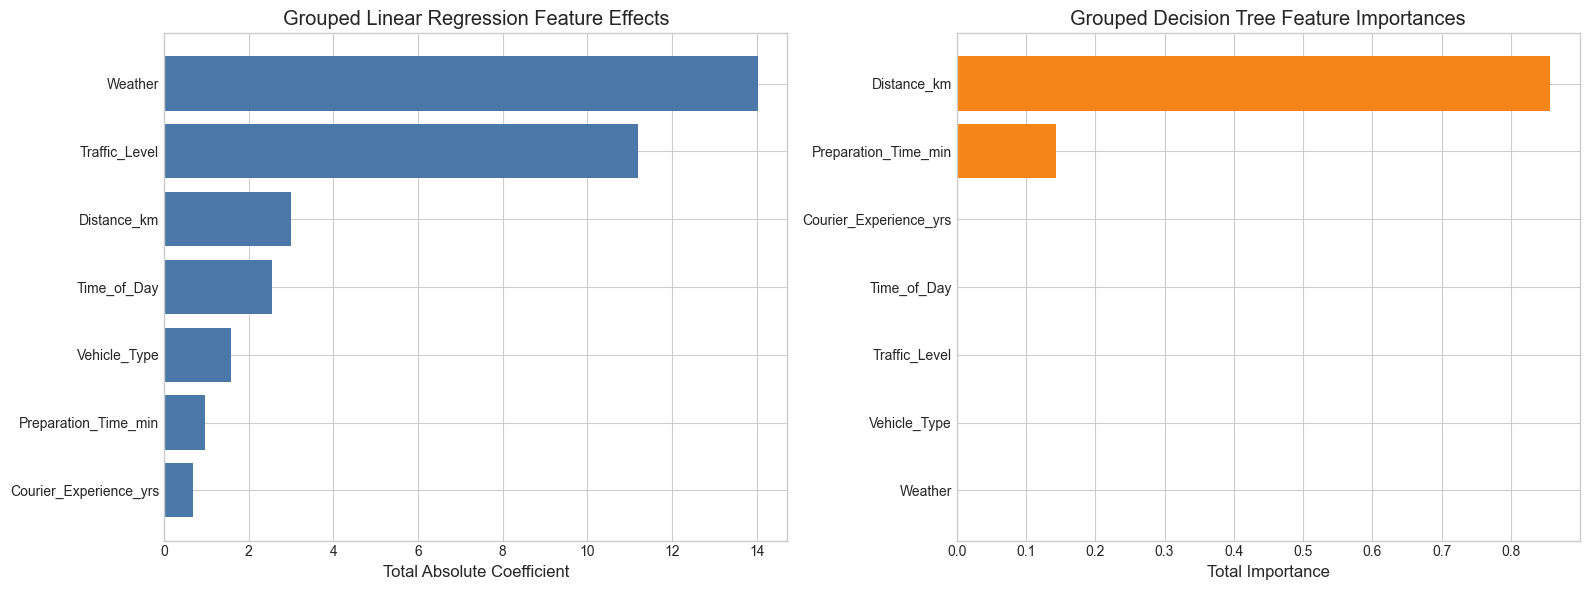

Top detailed Linear Regression effects:


,Feature,Coefficient
9,cat__Traffic_Level_Low,-5.599
8,cat__Traffic_Level_High,5.526
6,cat__Weather_Snowy,5.017
3,cat__Weather_Clear,-4.230
0,num__Distance_km,3.001
7,cat__Weather_Windy,-2.783
4,cat__Weather_Foggy,1.587
14,cat__Time_of_Day_Night,-1.240
12,cat__Time_of_Day_Evening,1.140
1,num__Preparation_Time_min,0.969


Grouped feature influence summary:


,Original_Feature,Abs Coefficient,Importance,Combined Score
1,Distance_km,3.001,0.857,1.214
6,Weather,14.026,0.000,1.000
4,Traffic_Level,11.198,0.000,0.798
2,Preparation_Time_min,0.969,0.143,0.236
3,Time_of_Day,2.550,0.000,0.182
5,Vehicle_Type,1.592,0.000,0.113
0,Courier_Experience_yrs,0.677,0.000,0.048


Business insight summary:
1. The most influential drivers of delivery time are Distance_km, Weather, and Traffic_Level.
2. High preparation time and long travel distance usually increase the final delivery time prediction.
3. Traffic and time-of-day patterns suggest that operational planning can reduce delays during peak periods.


In [26]:
# Step 11: Explainability and business insights
transformed_feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
linear_coefficients = linear_model.named_steps["model"].coef_
tree_importances = tree_model.named_steps["model"].feature_importances_

def collapse_feature_name(feature_name):
    feature_name = feature_name.replace("num__", "").replace("cat__", "")
    normalized_feature_name = normalize_name(feature_name)
    for original_feature in X.columns:
        normalized_original = normalize_name(original_feature)
        if normalized_feature_name == normalized_original or normalized_feature_name.startswith(normalized_original + "_"):
            return original_feature
    return feature_name

linear_effects_df = pd.DataFrame(
    {
        "Feature": transformed_feature_names,
        "Coefficient": linear_coefficients,
        "Abs Coefficient": np.abs(linear_coefficients),
    }
).sort_values("Abs Coefficient", ascending=False)

tree_importance_df = pd.DataFrame(
    {
        "Feature": transformed_feature_names,
        "Importance": tree_importances,
    }
).sort_values("Importance", ascending=False)

grouped_linear_effects = (
    linear_effects_df.assign(Original_Feature=linear_effects_df["Feature"].map(collapse_feature_name))
    .groupby("Original_Feature", as_index=False)["Abs Coefficient"]
    .sum()
    .sort_values("Abs Coefficient", ascending=False)
)

grouped_tree_importance = (
    tree_importance_df.assign(Original_Feature=tree_importance_df["Feature"].map(collapse_feature_name))
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

top_linear_effects = linear_effects_df.head(10).copy()
top_grouped_linear = grouped_linear_effects.head(7).copy()
top_grouped_tree = grouped_tree_importance.head(7).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_grouped_linear["Original_Feature"][::-1], top_grouped_linear["Abs Coefficient"][::-1], color="#4c78a8")
axes[0].set_title("Grouped Linear Regression Feature Effects")
axes[0].set_xlabel("Total Absolute Coefficient")

axes[1].barh(top_grouped_tree["Original_Feature"][::-1], top_grouped_tree["Importance"][::-1], color="#f58518")
axes[1].set_title("Grouped Decision Tree Feature Importances")
axes[1].set_xlabel("Total Importance")

plt.tight_layout()
plt.show()

print("Top detailed Linear Regression effects:")
display(top_linear_effects[["Feature", "Coefficient"]].round(3))

print("Grouped feature influence summary:")
grouped_summary = top_grouped_linear.merge(top_grouped_tree, on="Original_Feature", how="outer").fillna(0)
grouped_summary["Combined Score"] = (
    grouped_summary["Abs Coefficient"] / grouped_summary["Abs Coefficient"].max()
    + grouped_summary["Importance"] / max(grouped_summary["Importance"].max(), 1e-9)
)
grouped_summary = grouped_summary.sort_values("Combined Score", ascending=False)
display(grouped_summary.round(3))

strongest_business_drivers = grouped_summary["Original_Feature"].tolist()[:3]

print("Business insight summary:")
print(
    f"1. The most influential drivers of delivery time are {strongest_business_drivers[0]}, "
    f"{strongest_business_drivers[1]}, and {strongest_business_drivers[2]}."
)
print("2. High preparation time and long travel distance usually increase the final delivery time prediction.")
print("3. Traffic and time-of-day patterns suggest that operational planning can reduce delays during peak periods.")


## Final Conclusion

This project predicts food delivery time using multiple machine learning models and compares them with both visual and quantitative analysis.

Final conclusion:
- Linear Regression is the better final model for this dataset because it gives lower error and higher R2 than the shallow Decision Tree.
- Removing `Order_ID` improves the project quality because identifiers should not be treated as meaningful business predictors.
- Cross-validation supports the final choice by showing that Linear Regression remains more stable across multiple splits.
- Explainability charts show that distance, preparation time, traffic conditions, and time-of-day are the main drivers of delivery time.

Future improvements:
- collect more real-world features such as restaurant load, delivery partner availability, and festival or weather severity levels
- test ensemble models such as Random Forest or Gradient Boosting
- deploy the model as a small app or dashboard for live prediction


In [27]:
# Step 12: Save model and metadata
with open("model.pkl", "wb") as f:
    pickle.dump(linear_model, f)

model_info = {
    "target_column": target_col,
    "feature_columns": list(X.columns),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "removed_identifier_columns": identifier_columns,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "metrics": {
        "linear_regression": {
            "mae": float(mae_linear),
            "rmse": float(rmse_linear),
            "mape_percent": float(mape_linear),
            "r2": float(r2_linear),
        },
        "decision_tree_shallow": {
            "mae": float(mae_tree),
            "rmse": float(rmse_tree),
            "mape_percent": float(mape_tree),
            "r2": float(r2_tree),
        },
    },
    "cross_validation": {
        row_name: {metric: float(value) for metric, value in row.items()}
        for row_name, row in cv_df.to_dict(orient="index").items()
    },
    "order_id_experiment": {
        row_name: {metric: float(value) for metric, value in row.items()}
        for row_name, row in id_experiment_df.to_dict(orient="index").items()
    },
}

with open("model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved model.pkl and model_info.json")


Saved model.pkl and model_info.json


## Step 13: Predict for One New Entry (No New CSV)
Run the next cell and enter values one by one.


In [28]:
# Single-entry prediction

def predict_single_entry(model, info):
    target = info["target_column"]
    feature_cols = list(X.columns)
    numeric = set(numeric_features)

    row = {}
    print("Enter new order details. Press Enter to skip any field.")
    for col in feature_cols:
        raw = input(f"{col}: ").strip()
        if raw == "":
            row[col] = np.nan
        elif col in numeric:
            try:
                row[col] = float(raw)
            except ValueError:
                row[col] = np.nan
        else:
            row[col] = raw

    X_new = pd.DataFrame([row], columns=feature_cols)
    pred = float(model.predict(X_new)[0])
    print(f"Predicted {target}: {pred:.2f}")

predict_single_entry(linear_model, model_info)


Enter new order details. Press Enter to skip any field.
Predicted Delivery_Time_min: 32.26
